In [1]:
import vitaldb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import resample_poly
from tqdm import tqdm

In [2]:
# Find cases containing arterial pressure
abp_cases = vitaldb.find_cases(['ART'])

print("Cases with ART:", len(abp_cases))
print(abp_cases[:20])

/tmp/ipykernel_2045815/3920463723.py:2: DeprecationWarning: find_cases() relies on the per-track 'trks' index, which is deprecated and may be removed in a future release.
  abp_cases = vitaldb.find_cases(['ART'])


Cases with ART: 3645
[1, 3, 4, 7, 10, 12, 13, 14, 16, 17, 19, 20, 22, 24, 25, 26, 27, 28, 29, 31]


In [3]:
ppg_cases = vitaldb.find_cases(['PLETH'])

print("Cases with PLETH:", len(ppg_cases))
print(ppg_cases[:20])

Cases with PLETH: 6157
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21]


/tmp/ipykernel_2045815/195122844.py:1: DeprecationWarning: find_cases() relies on the per-track 'trks' index, which is deprecated and may be removed in a future release.
  ppg_cases = vitaldb.find_cases(['PLETH'])


In [4]:
common_cases = sorted(
    set(abp_cases).intersection(ppg_cases)
)

print("Cases with both PPG and ABP:", len(common_cases))
print(common_cases[:20])

Cases with both PPG and ABP: 3459
[1, 3, 4, 7, 10, 13, 14, 16, 17, 19, 20, 22, 24, 25, 26, 27, 28, 29, 31, 32]


In [ ]:
print(
    vitaldb.find_cases(['SNUADC/PLETH'])[:10]
)

print(
    vitaldb.find_cases(['SNUADC/ART'])[:10]
)

In [ ]:
valid_common_cases = []

missing_ppg = []
missing_art = []
failed_cases = []

for case_id in tqdm(common_cases):

    try:
        vf = vitaldb.VitalFile(case_id)

        tracks = set(vf.trks.keys())

        has_ppg = "SNUADC/PLETH" in tracks
        has_art = "SNUADC/ART" in tracks

        if has_ppg and has_art:

            valid_common_cases.append(case_id)

        else:

            if not has_ppg:
                missing_ppg.append(case_id)

            if not has_art:
                missing_art.append(case_id)

    except Exception as e:

        failed_cases.append(case_id)

        print(
            f"\nFailed case {case_id}: "
            f"{type(e).__name__}: {e}"
        )

        continue


# -----------------------------------------
# Remove failed cases from common_cases
# -----------------------------------------

common_cases = [
    case_id
    for case_id in common_cases
    if case_id not in failed_cases
]


# -----------------------------------------
# Results
# -----------------------------------------

print("\n========================================")
print("RESULTS")
print("========================================")

print(
    "Original cases:",
    len(common_cases) + len(failed_cases)
)

print(
    "Failed cases removed:",
    len(failed_cases)
)

print(
    "Remaining common cases:",
    len(common_cases)
)

print(
    "Valid cases with BOTH waveforms:",
    len(valid_common_cases)
)

print(
    "Missing PPG:",
    len(missing_ppg)
)

print(
    "Missing ART:",
    len(missing_art)
)

 20%|██        | 704/3459 [17:04<1:11:15,  1.55s/it]


Failed case 1280: URLError: <urlopen error [Errno -2] Name or service not known>


 47%|████▋     | 1617/3459 [43:20<4:03:42,  7.94s/it] 


Failed case 2998: URLError: <urlopen error [Errno -2] Name or service not known>


 77%|███████▋  | 2658/3459 [3:41:12<55:36,  4.17s/it]      


Failed case 4934: URLError: <urlopen error [Errno -2] Name or service not known>

Failed case 4935: URLError: <urlopen error [Errno -2] Name or service not known>


 85%|████████▌ | 2946/3459 [4:08:04<45:05,  5.27s/it]  


Failed case 5454: URLError: <urlopen error [SSL: WRONG_VERSION_NUMBER] wrong version number (_ssl.c:1007)>


 91%|█████████ | 3152/3459 [4:31:01<31:47,  6.21s/it]  

In [17]:
for case_id in [616, common_cases[1], common_cases[2]]:
    try:
        vf = vitaldb.VitalFile(case_id)
        print("SUCCESS:", case_id)
    except Exception as e:
        print("FAILED:", case_id)
        print(type(e).__name__, e)

SUCCESS: 616
SUCCESS: 3
SUCCESS: 4


In [10]:
case_id = 3
vf = vitaldb.VitalFile(case_id)
data = vf.to_numpy(
    [
        "SNUADC/PLETH",
        "SNUADC/ART"
    ],
    interval=1/500
)

ppg = data[:, 0]
art = data[:, 1]

print("Data shape:", data.shape)
print("PPG shape:", ppg.shape)
print("ART shape:", art.shape)

Data shape: (2197087, 2)
PPG shape: (2197087,)
ART shape: (2197087,)


In [11]:
vf = vitaldb.VitalFile(case_id)

tracks = vf.get_track_names()

for track in tracks:
    if 'PLETH' in track.upper() or 'ART' in track.upper():
        print(track)

Solar8000/PLETH_SPO2
Solar8000/PLETH_HR
SNUADC/PLETH


In [7]:
ppg_track = vf.trks["SNUADC/PLETH"]
art_track = vf.trks["SNUADC/ART"]

print("PPG sampling rate:", ppg_track.srate)
print("ART sampling rate:", art_track.srate)

KeyError: 'SNUADC/ART'

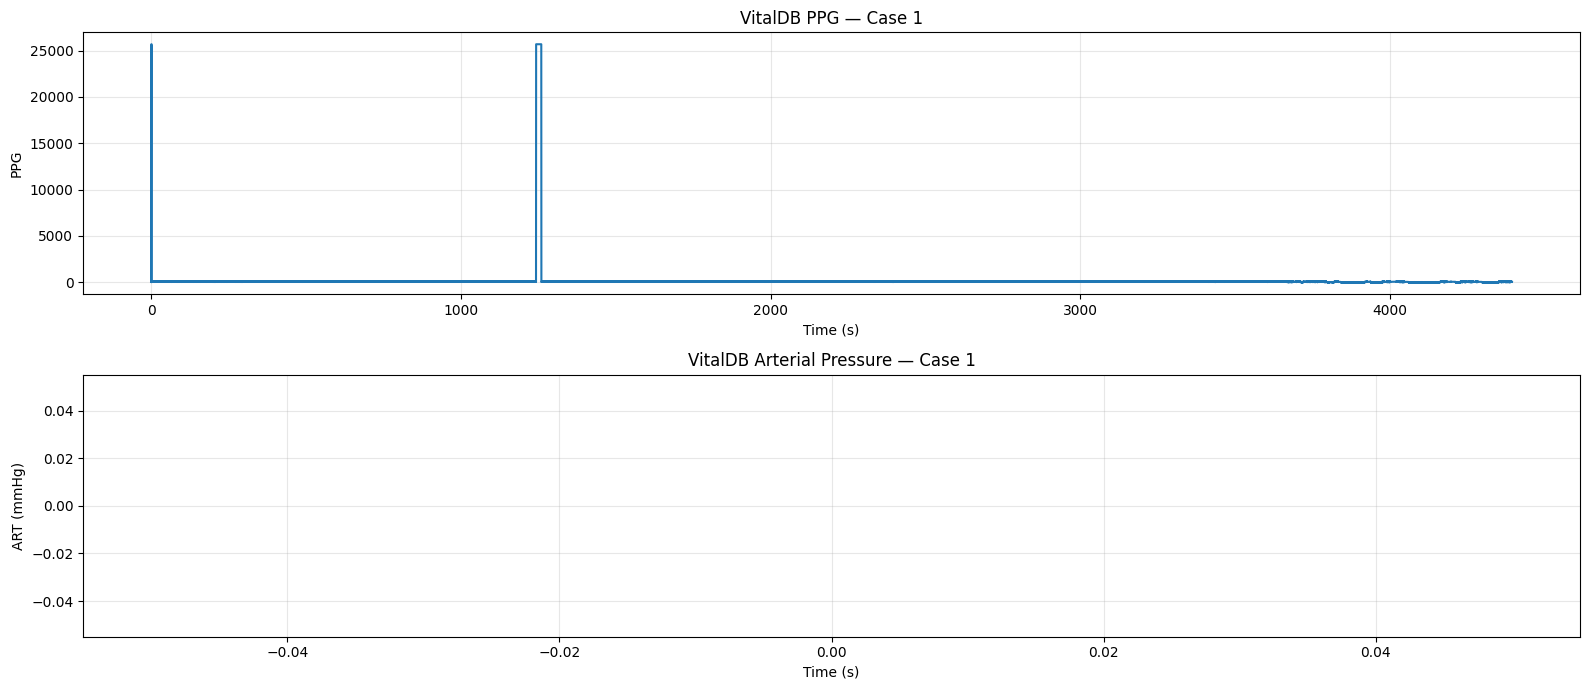

In [ ]:
fs = 500

N = len(ppg)

time = np.arange(N) / fs

plt.figure(figsize=(16, 7))

plt.subplot(2, 1, 1)

plt.plot(
    time,
    ppg
)

plt.xlabel("Time (s)")
plt.ylabel("PPG")
plt.title(f"VitalDB PPG — Case {case_id}")
plt.grid(alpha=0.3)


plt.subplot(2, 1, 2)

plt.plot(
    time,
    art
)

plt.xlabel("Time (s)")
plt.ylabel("ART (mmHg)")
plt.title(f"VitalDB Arterial Pressure — Case {case_id}")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

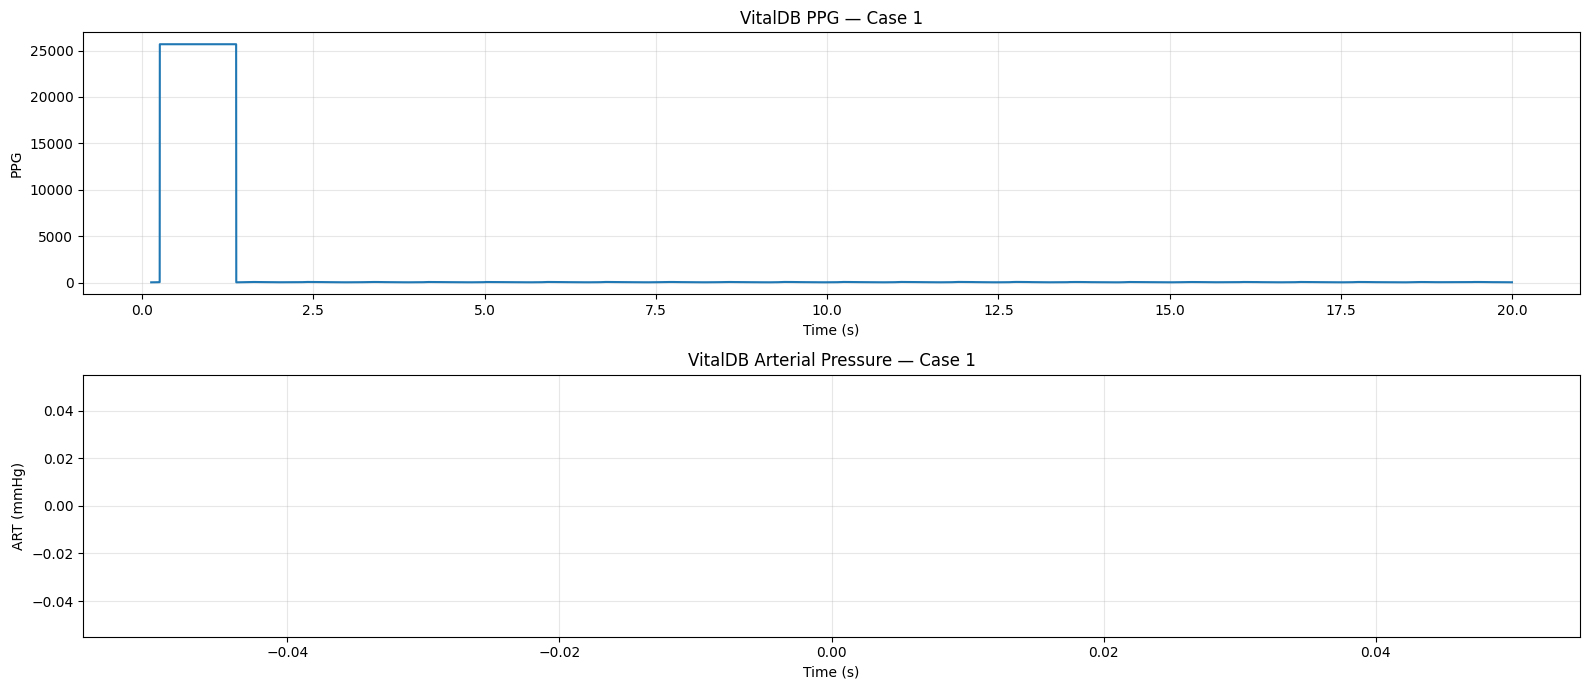

In [ ]:
fs = 500
duration = 20

N = int(fs * duration)

time = np.arange(N) / fs

plt.figure(figsize=(16, 7))

plt.subplot(2, 1, 1)

plt.plot(
    time,
    ppg[:N]
)

plt.xlabel("Time (s)")
plt.ylabel("PPG")
plt.title(f"VitalDB PPG — Case {case_id}")
plt.grid(alpha=0.3)


plt.subplot(2, 1, 2)

plt.plot(
    time,
    art[:N]
)

plt.xlabel("Time (s)")
plt.ylabel("ART (mmHg)")
plt.title(f"VitalDB Arterial Pressure — Case {case_id}")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("PPG:")
print("min =", np.nanmin(ppg))
print("max =", np.nanmax(ppg))
print("mean =", np.nanmean(ppg))
print("std =", np.nanstd(ppg))

print("\nABP:")
print("min =", np.nanmin(art))
print("max =", np.nanmax(art))
print("mean =", np.nanmean(art))
print("std =", np.nanstd(art))

PPG:
min = -198.2504
max = 97.19675
mean = 39.908978
std = 11.125543

ABP:
min = -495.626
max = 305.20163
mean = 75.18822
std = 28.148708


## Downsampling ##

Vital DB dataset is sampled at 500Hz but UCI is at 125Hz. For zero-shot learning we thus need to downsample vital db dataset

In [ ]:
def downsample_signal(signal, original_fs=500, target_fs=125):
    signal = np.asarray(signal, dtype=np.float32)

    # 500 Hz → 125 Hz = downsample by 4
    downsampled = resample_poly(
        signal,
        up=1,
        down=4
    )

    return downsampled.astype(np.float32)

In [ ]:
ppg_500 = ppg  # 8 sec at 500 Hz
art_500 = art

ppg_125 = downsample_signal(
    ppg_500
)

print("Original shape:", ppg_500.shape)
print("Downsampled shape:", ppg_125.shape)


Original shape: (13237788,)
Downsampled shape: (3309447,)


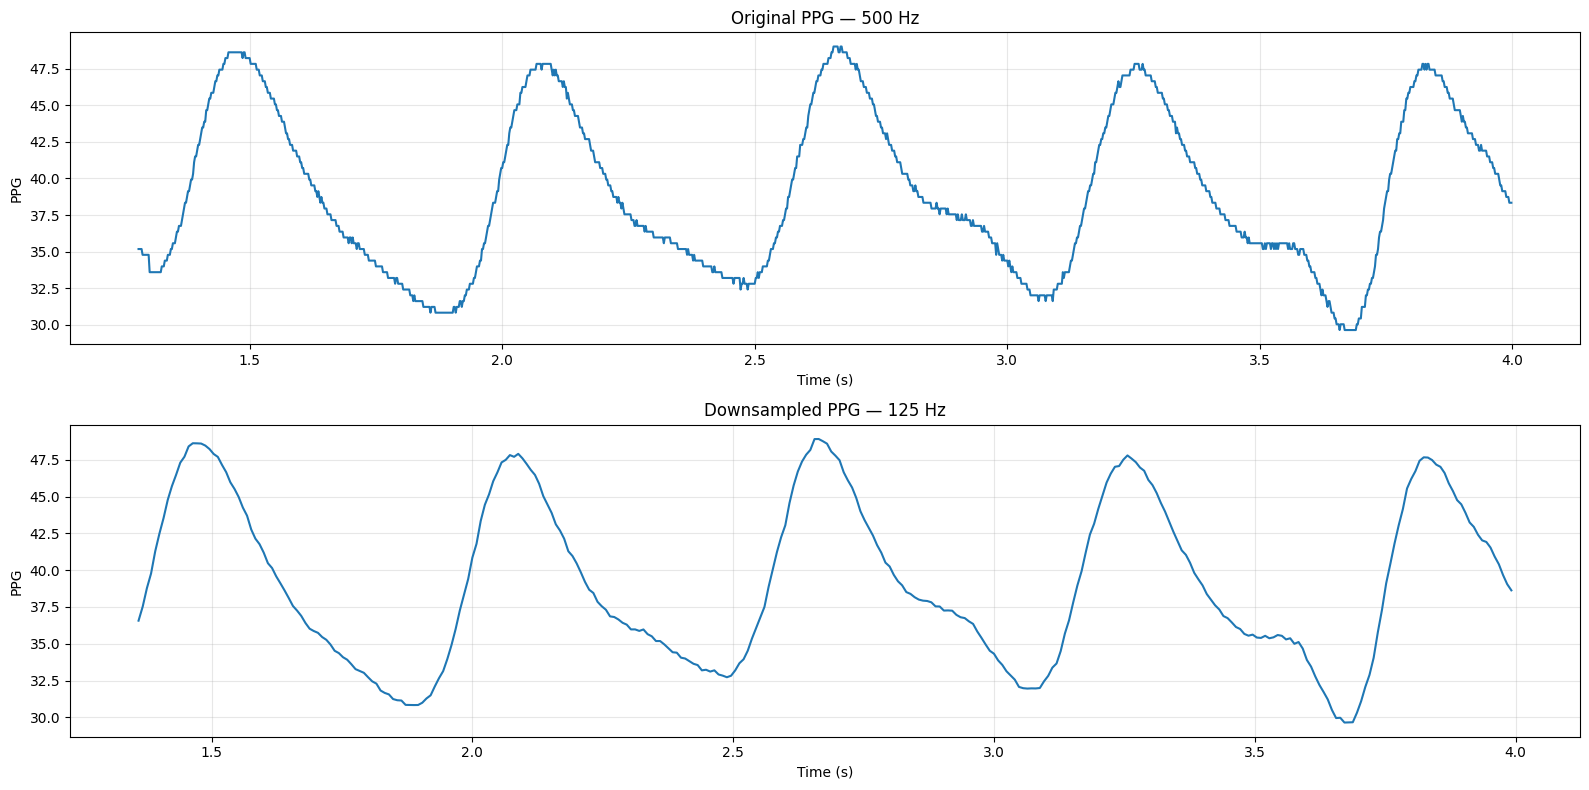

In [ ]:
fs_original = 500
fs = 125

time_original = np.arange(len(ppg)) / fs_original
time = np.arange(len(ppg_125)) / fs

plt.figure(figsize=(16, 8))

# -----------------------------------------
# Original PPG
# -----------------------------------------
plt.subplot(2, 1, 1)

plt.plot(
    time_original[:2000],
    ppg[:2000]
)

plt.xlabel("Time (s)")
plt.ylabel("PPG")
plt.title("Original PPG — 500 Hz")
plt.grid(alpha=0.3)


# -----------------------------------------
# Downsampled PPG
# -----------------------------------------
plt.subplot(2, 1, 2)

plt.plot(
    time[:500],
    ppg_125[:500]
)

plt.xlabel("Time (s)")
plt.ylabel("PPG")
plt.title("Downsampled PPG — 125 Hz")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import vitaldb
import numpy as np
import pandas as pd
from tqdm import tqdm


def check_common_cases(common_cases):

    results = []

    for case_id in tqdm(common_cases):

        try:

            vf = vitaldb.VitalFile(case_id)

            # -----------------------------------------
            # Get raw waveform tracks
            # -----------------------------------------

            ppg_track = vf.trks["SNUADC/PLETH"]
            art_track = vf.trks["SNUADC/ART"]

            # We know these tracks contain one waveform
            # record in the cases we've inspected
            ppg_rec = ppg_track.recs[0]
            art_rec = art_track.recs[0]

            ppg = np.asarray(ppg_rec["val"])
            art = np.asarray(art_rec["val"])

            # -----------------------------------------
            # Sampling rates
            # -----------------------------------------

            ppg_fs = float(ppg_track.srate)
            art_fs = float(art_track.srate)

            # -----------------------------------------
            # Number of samples
            # -----------------------------------------

            ppg_samples = len(ppg)
            art_samples = len(art)

            # -----------------------------------------
            # Start timestamps
            # -----------------------------------------

            ppg_start = float(ppg_rec["dt"])
            art_start = float(art_rec["dt"])

            # -----------------------------------------
            # Duration
            # -----------------------------------------

            ppg_duration = (
                ppg_samples / ppg_fs
            )

            art_duration = (
                art_samples / art_fs
            )

            # -----------------------------------------
            # End timestamps
            # -----------------------------------------

            ppg_end = (
                ppg_start
                + (ppg_samples - 1) / ppg_fs
            )

            art_end = (
                art_start
                + (art_samples - 1) / art_fs
            )

            # -----------------------------------------
            # Start / end differences
            # -----------------------------------------

            start_difference = (
                ppg_start - art_start
            )

            end_difference = (
                ppg_end - art_end
            )

            # -----------------------------------------
            # NaNs
            # -----------------------------------------

            ppg_nan = np.isnan(ppg).sum()
            art_nan = np.isnan(art).sum()

            ppg_nan_pct = (
                np.isnan(ppg).mean() * 100
            )

            art_nan_pct = (
                np.isnan(art).mean() * 100
            )

            # -----------------------------------------
            # Length and timing checks
            # -----------------------------------------

            same_length = (
                ppg_samples == art_samples
            )

            same_start = np.isclose(
                ppg_start,
                art_start
            )

            same_end = np.isclose(
                ppg_end,
                art_end
            )

            # -----------------------------------------
            # Store everything
            # -----------------------------------------

            results.append({

                "case_id": case_id,

                # Sampling
                "ppg_fs": ppg_fs,
                "art_fs": art_fs,

                # Number of samples
                "ppg_samples": ppg_samples,
                "art_samples": art_samples,
                "sample_difference":
                    ppg_samples - art_samples,

                # Duration
                "ppg_duration_sec": ppg_duration,
                "art_duration_sec": art_duration,
                "duration_difference_sec":
                    ppg_duration - art_duration,

                # Start times
                "ppg_start": ppg_start,
                "art_start": art_start,
                "start_difference_sec":
                    start_difference,

                # End times
                "ppg_end": ppg_end,
                "art_end": art_end,
                "end_difference_sec":
                    end_difference,

                # NaNs
                "ppg_nan": ppg_nan,
                "art_nan": art_nan,

                "ppg_nan_pct": ppg_nan_pct,
                "art_nan_pct": art_nan_pct,

                # Checks
                "same_length": same_length,
                "same_start": same_start,
                "same_end": same_end
            })

        except Exception as e:

            print(
                f"Error in case {case_id}: {e}"
            )

    return pd.DataFrame(results)

In [ ]:
nan_df = check_common_cases(common_cases)

print(nan_df)

  0%|          | 0/10 [00:00<?, ?it/s]

Error in case 1: <urlopen error [Errno -2] Name or service not known>


 20%|██        | 2/10 [00:00<00:02,  3.37it/s]

Error in case 3: 'SNUADC/ART'


 70%|███████   | 7/10 [00:07<00:03,  1.10s/it]

Error in case 14: 'SNUADC/ART'


100%|██████████| 10/10 [00:16<00:00,  1.66s/it]


   case_id  ppg_fs  art_fs  ppg_samples  art_samples  sample_difference  \
0        4   500.0   500.0     10494700     10494700                  0   
1        7   500.0   500.0      7884622      7884622                  0   
2       10   500.0   500.0     10494050     10494050                  0   
3       13   500.0   500.0      5405175      5405175                  0   
4       16   500.0   500.0      6432054      6432054                  0   
5       17   500.0   500.0     10184150     10184150                  0   
6       19   500.0   500.0     13785526     13785526                  0   

   ppg_duration_sec  art_duration_sec  duration_difference_sec     ppg_start  \
0         20989.400         20989.400                      0.0  4.102445e+09   
1         15769.244         15769.244                      0.0  4.102445e+09   
2         20988.100         20988.100                      0.0  4.102445e+09   
3         10810.350         10810.350                      0.0  4.102445e+09   

In [ ]:
different_length = nan_df[
    nan_df["same_length"] == False
]

print(
    "Cases with different PPG/ART lengths:",
    len(different_length)
)

print(
    different_length[
        [
            "case_id",
            "ppg_samples",
            "art_samples",
            "sample_difference",
            "ppg_duration_sec",
            "art_duration_sec",
            "ppg_start",
            "art_start",
            "start_difference_sec",
            "ppg_end",
            "art_end",
            "end_difference_sec"
        ]
    ]
)

Cases with different PPG/ART lengths: 0
Empty DataFrame
Columns: [case_id, ppg_samples, art_samples, sample_difference, ppg_duration_sec, art_duration_sec, ppg_start, art_start, start_difference_sec, ppg_end, art_end, end_difference_sec]
Index: []


In [ ]:
print("\n======================================")
print("SUMMARY")
print("======================================")

print(
    "Total common cases:",
    len(nan_df)
)

print(
    "Cases with PPG NaNs:",
    (nan_df["ppg_nan"] > 0).sum()
)

print(
    "Cases with ART NaNs:",
    (nan_df["art_nan"] > 0).sum()
)

print(
    "Cases with NO PPG NaNs:",
    (nan_df["ppg_nan"] == 0).sum()
)

print(
    "Cases with NO ART NaNs:",
    (nan_df["art_nan"] == 0).sum()
)


SUMMARY
Total common cases: 10
Cases with PPG NaNs: 0
Cases with ART NaNs: 0
Cases with NO PPG NaNs: 8
Cases with NO ART NaNs: 8


In [ ]:
same_length = (
    nan_df["ppg_samples"]
    ==
    nan_df["art_samples"]
)

print(
    "\nCases with same PPG and ART length:",
    same_length.sum()
)

print(
    "Cases with different lengths:",
    (~same_length).sum()
)


Cases with same PPG and ART length: 8
Cases with different lengths: 0
